<a href="https://colab.research.google.com/github/Ariel-Pineapple/qc-anomaly-detection-isolation-forest/blob/main/03_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

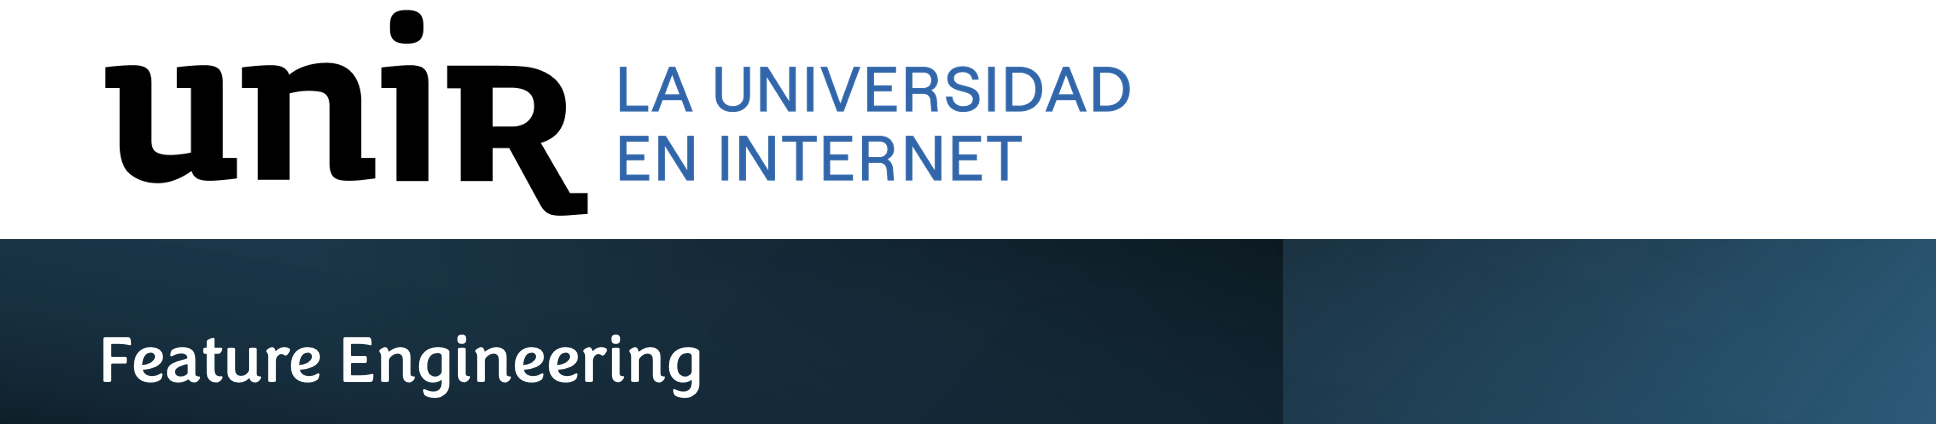

# Feature Engineering para detección de anomalías en control de calidad

## Objetivo

Construir variables derivadas a partir de la serie temporal de valores S/CO que permitan capturar patrones de variabilidad, tendencia y desviación respecto a la línea base, con el fin de mejorar la capacidad de detección de anomalías del modelo Isolation Forest.

## Enfoque

Se diseñan features interpretables basadas en:
- Estadística móvil (media y desviación)
- Cambios temporales (deltas)
- Desviaciones estandarizadas (z-score)
- Contexto operativo (lote y comportamiento reciente)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("dataset_qc_sintetico.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

df.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift
0,1,2025-01-01,VIH,L001,E01,1.0248,0,normal
1,2,2025-01-02,VIH,L001,E01,0.9931,0,normal
2,3,2025-01-03,VIH,L001,E01,1.0324,0,normal
3,4,2025-01-04,VIH,L001,E01,1.0762,0,normal
4,5,2025-01-05,VIH,L001,E01,0.9883,0,normal


## 2. Inspección inicial del dataset

Antes de construir variables derivadas, se verifica la estructura general del dataset, el tipo de datos y la ausencia de valores nulos, con el fin de asegurar consistencia en el procesamiento temporal.

In [14]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_registro       360 non-null    int64         
 1   fecha             360 non-null    datetime64[ns]
 2   analito           360 non-null    object        
 3   lote              360 non-null    object        
 4   equipo            360 non-null    object        
 5   sco               360 non-null    float64       
 6   estado_real       360 non-null    int64         
 7   tipo_drift        360 non-null    object        
 8   rolling_mean_5    356 non-null    float64       
 9   rolling_std_5     356 non-null    float64       
 10  delta             359 non-null    float64       
 11  zscore_dynamic    356 non-null    float64       
 12  drift             356 non-null    float64       
 13  alert_2s          360 non-null    int64         
 14  rolling_alerts_5  356 non-

,0
id_registro,0
fecha,0
analito,0
lote,0
equipo,0
sco,0
estado_real,0
tipo_drift,0
rolling_mean_5,4
rolling_std_5,4


## 3. Media móvil (rolling mean)

Se calcula la media móvil para capturar el comportamiento local del proceso, permitiendo identificar desplazamientos graduales (drift).

In [3]:
window = 5

df["rolling_mean_5"] = df["sco"].rolling(window=window).mean()

Se define una ventana móvil de 5 observaciones para capturar comportamiento local sin suavizar en exceso la señal. Este tamaño permite identificar cambios graduales en el proceso manteniendo sensibilidad a variaciones recientes.

## 4. Desviación estándar móvil

Permite identificar incrementos en la variabilidad, los cuales pueden indicar inestabilidad del proceso.

In [15]:
df["rolling_std_5"] = df["rolling_std_5"].replace(0, np.nan)

df["zscore_dynamic"] = (
    (df["sco"] - df["rolling_mean_5"]) / df["rolling_std_5"]
)

Para evitar divisiones por cero o valores inestables, las desviaciones estándar móviles iguales a cero se sustituyen por valores nulos antes del cálculo del z-score dinámico.

## 5. Cambio entre observaciones consecutivas (delta)

Captura variaciones abruptas entre mediciones consecutivas.

In [5]:
df["delta"] = df["sco"].diff()

## 6. Z-score dinámico

Se calcula una desviación estandarizada basada en la media y desviación móvil, lo cual permite adaptar la referencia al contexto local.

In [6]:
df["zscore_dynamic"] = (
    (df["sco"] - df["rolling_mean_5"]) / df["rolling_std_5"]
)

## 7. Drift acumulado

Se mide la desviación acumulada respecto a la media móvil, lo cual permite identificar tendencias sostenidas.

In [7]:
df["drift"] = df["sco"] - df["rolling_mean_5"]

## 8. Conteo de alertas recientes

Se calcula cuántas observaciones recientes han superado el umbral de ±2 desviaciones estándar.

In [8]:
df["alert_2s"] = (df["zscore_dynamic"].abs() > 2).astype(int)
df["rolling_alerts_5"] = df["alert_2s"].rolling(window=5).sum()

## 9. Cambio relativo

Permite identificar variaciones proporcionales en lugar de absolutas.


In [9]:
df["pct_change"] = df["sco"].pct_change()

## 10. Limpieza de valores nulos

Las variables basadas en ventanas generan valores nulos en los primeros registros, los cuales se eliminan para el modelado.

In [10]:
df_features = df.dropna().reset_index(drop=True)
df_features.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift,rolling_mean_5,rolling_std_5,delta,zscore_dynamic,drift,alert_2s,rolling_alerts_5,pct_change
0,5,2025-01-05,VIH,L001,E01,0.9883,0,normal,1.02296,0.035426,-0.0879,-0.978385,-0.03466,0,0.0,-0.081676
1,6,2025-01-06,VIH,L001,E01,0.9883,0,normal,1.01566,0.038573,0.0000,-0.709310,-0.02736,0,0.0,0.000000
2,7,2025-01-07,VIH,L001,E01,1.0790,0,normal,1.03284,0.044662,0.0907,1.033549,0.04616,0,0.0,0.091774
3,8,2025-01-08,VIH,L001,E01,1.0384,0,normal,1.03404,0.044727,-0.0406,0.097479,0.00436,0,0.0,-0.037627
4,9,2025-01-09,VIH,L001,E01,0.9765,0,normal,1.01410,0.043438,-0.0619,-0.865596,-0.03760,0,0.0,-0.059611


In [16]:
df_features[[
    "fecha", "sco", "rolling_mean_5", "rolling_std_5",
    "delta", "zscore_dynamic", "drift",
    "rolling_alerts_5", "pct_change", "estado_real", "tipo_drift"
]].head(10)

,fecha,sco,rolling_mean_5,rolling_std_5,delta,zscore_dynamic,drift,rolling_alerts_5,pct_change,estado_real,tipo_drift
0,2025-01-05,0.9883,1.02296,0.035426,-0.0879,-0.978385,-0.03466,0.0,-0.081676,0,normal
1,2025-01-06,0.9883,1.01566,0.038573,0.0000,-0.709310,-0.02736,0.0,0.000000,0,normal
2,2025-01-07,1.0790,1.03284,0.044662,0.0907,1.033549,0.04616,0.0,0.091774,0,normal
3,2025-01-08,1.0384,1.03404,0.044727,-0.0406,0.097479,0.00436,0.0,-0.037627,0,normal
4,2025-01-09,0.9765,1.01410,0.043438,-0.0619,-0.865596,-0.03760,0.0,-0.059611,0,normal
5,2025-01-10,1.0271,1.02186,0.041079,0.0506,0.127560,0.00524,0.0,0.051818,0,normal
6,2025-01-11,0.9768,1.01956,0.043668,-0.0503,-0.979212,-0.04276,0.0,-0.048973,0,normal
7,2025-01-12,0.9767,0.99910,0.030977,-0.0001,-0.723117,-0.02240,0.0,-0.000102,0,normal
8,2025-01-13,1.0121,0.99384,0.024106,0.0354,0.757476,0.01826,0.0,0.036244,0,normal
9,2025-01-14,0.9043,0.97940,0.047431,-0.1078,-1.583367,-0.07510,0.0,-0.106511,0,normal


La tabla anterior permite observar cómo las variables derivadas transforman la señal original en una representación más rica del comportamiento del proceso. Estas features serán la base de entrada del modelo de detección de anomalías.

## 11. Selección de variables para el modelo

Se seleccionan variables que capturan:
- Nivel (rolling_mean)
- Variabilidad (rolling_std)
- Cambio (delta, pct_change)
- Desviación (zscore)
- Tendencia (drift)
- Persistencia de anomalías (rolling alerts)

In [19]:
features = [
    "sco",
    "rolling_mean_5",
    "rolling_std_5",
    "delta",
    "zscore_dynamic",
    "drift",
    "rolling_alerts_5"
]

X = df_features[features]
y = df_features["estado_real"]

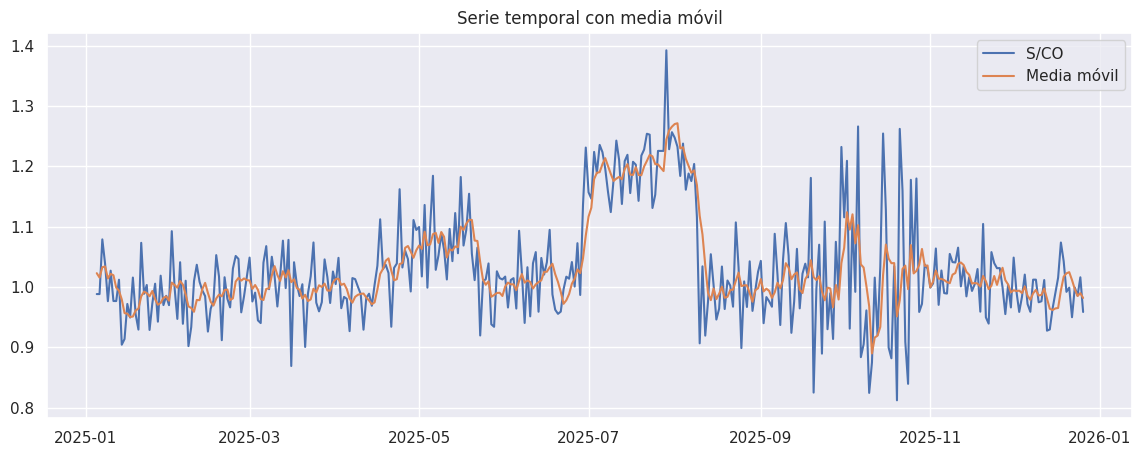

In [20]:
plt.figure(figsize=(14,5))
plt.plot(df_features["fecha"], df_features["sco"], label="S/CO")

plt.plot(df_features["fecha"], df_features["rolling_mean_5"], label="Media móvil")

plt.title("Serie temporal con media móvil")
plt.legend()
plt.show()

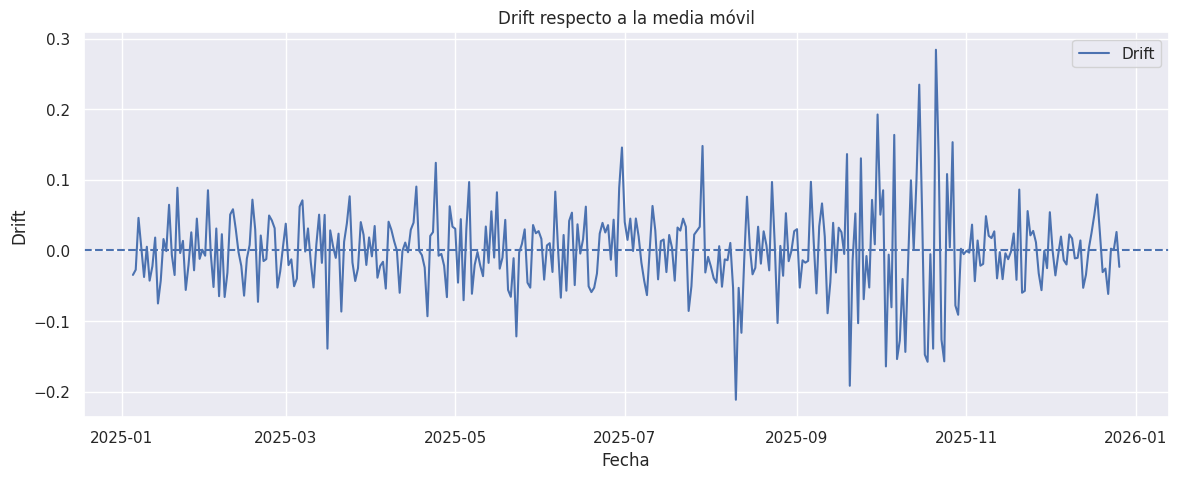

In [21]:
plt.figure(figsize=(14,5))
plt.plot(df_features["fecha"], df_features["drift"], label="Drift")
plt.axhline(0, linestyle="--")
plt.title("Drift respecto a la media móvil")
plt.xlabel("Fecha")
plt.ylabel("Drift")
plt.legend()
plt.show()

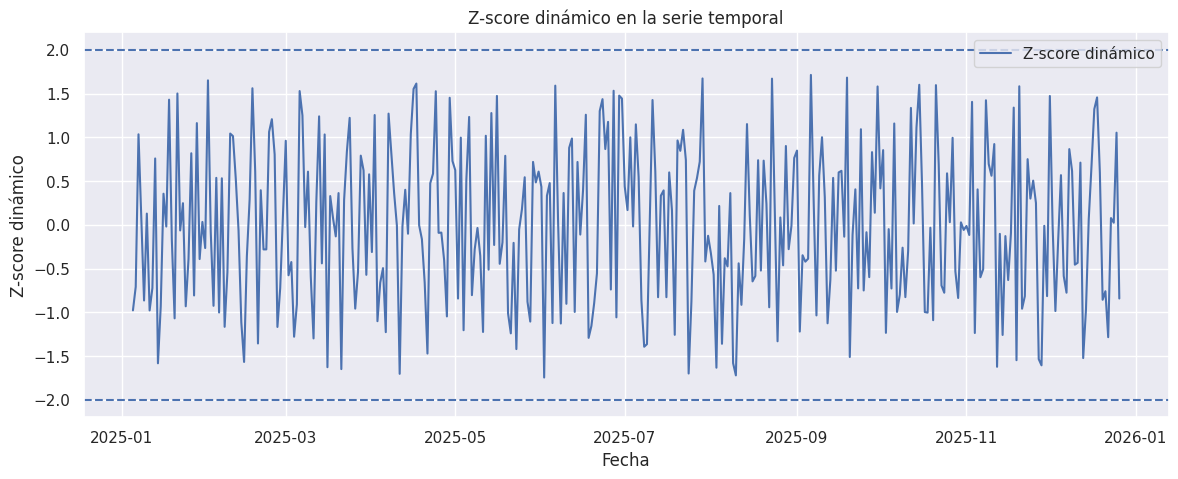

In [22]:
plt.figure(figsize=(14,5))
plt.plot(df_features["fecha"], df_features["zscore_dynamic"], label="Z-score dinámico")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Z-score dinámico en la serie temporal")
plt.xlabel("Fecha")
plt.ylabel("Z-score dinámico")
plt.legend()
plt.show()

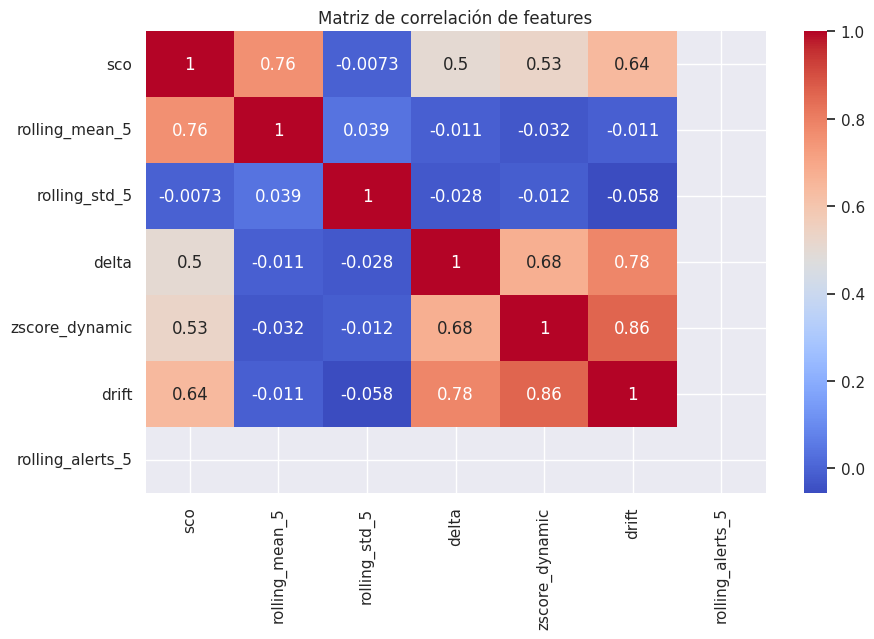

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación de features")
plt.show()

La matriz de correlación muestra alta asociación entre algunas variables derivadas, particularmente entre `delta` y `pct_change`, así como entre `drift` y `zscore_dynamic`. Esto sugiere posible redundancia informativa, por lo que en etapas posteriores se evaluará si conviene conservar todas las variables o simplificar el conjunto de entrada del modelo.

In [24]:
df_features.groupby("estado_real")[[
    "sco", "rolling_mean_5", "rolling_std_5",
    "delta", "zscore_dynamic", "drift", "rolling_alerts_5"
]].mean()

,sco,rolling_mean_5,rolling_std_5,delta,zscore_dynamic,drift,rolling_alerts_5
estado_real,,,,,,,
0,0.999741,1.002726,0.045859,-0.001670,-0.034956,-0.002985,0.0
1,1.094298,1.089361,0.074771,0.002305,0.071814,0.004937,0.0


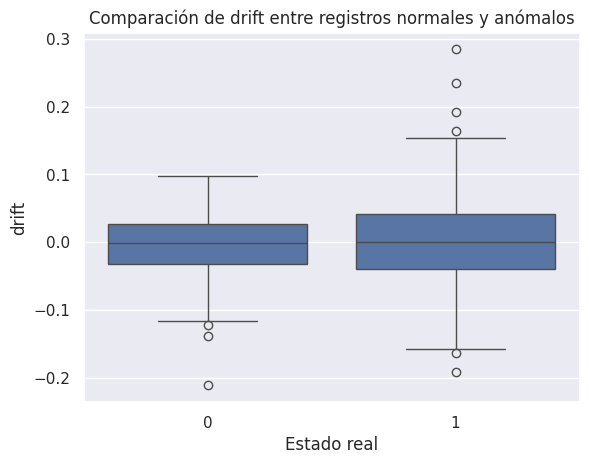

In [25]:
sns.boxplot(data=df_features, x="estado_real", y="drift")
plt.title("Comparación de drift entre registros normales y anómalos")
plt.xlabel("Estado real")
plt.show()

## 12. Conclusiones del Feature Engineering

Las variables derivadas construidas permiten capturar patrones temporales que no son observables mediante reglas estadísticas estáticas. En particular, las estadísticas móviles, las métricas de cambio y las variables de persistencia mejoran la representación del comportamiento del proceso.

Asimismo, el análisis exploratorio de las features muestra que algunas presentan alta correlación, lo que sugiere la necesidad de revisar redundancias antes del entrenamiento final. En conjunto, este conjunto de variables constituye una base adecuada para alimentar el modelo Isolation Forest en la siguiente etapa.

In [26]:
df_features.to_csv("dataset_qc_features.csv", index=False)

El dataset enriquecido con variables derivadas se exporta para su uso en la etapa de entrenamiento y validación del modelo.